# Car Price Prediction - Advanced Machine Learning Model

This notebook contains a complete workflow for predicting car prices. It includes data exploration, advanced feature engineering, and an ensemble model that achieves high accuracy.

## 1. Import Libraries
We use scikit-learn's `Pipeline` and `ColumnTransformer` for robust preprocessing.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [18]:
df = pd.read_csv('CarPrice_Assignment.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Exploratory Data Analysis (EDA)
Checking for missing values and understanding the distribution of the target variable `price`.

Null Values:
 car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


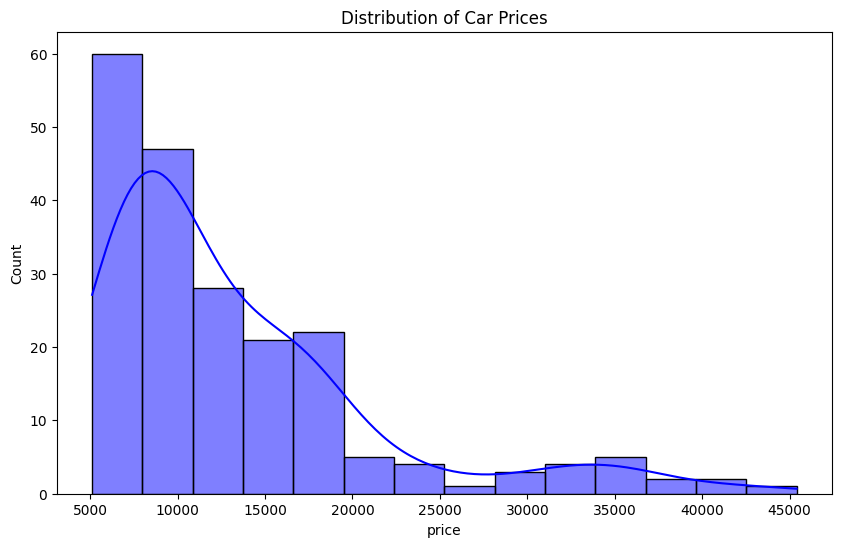

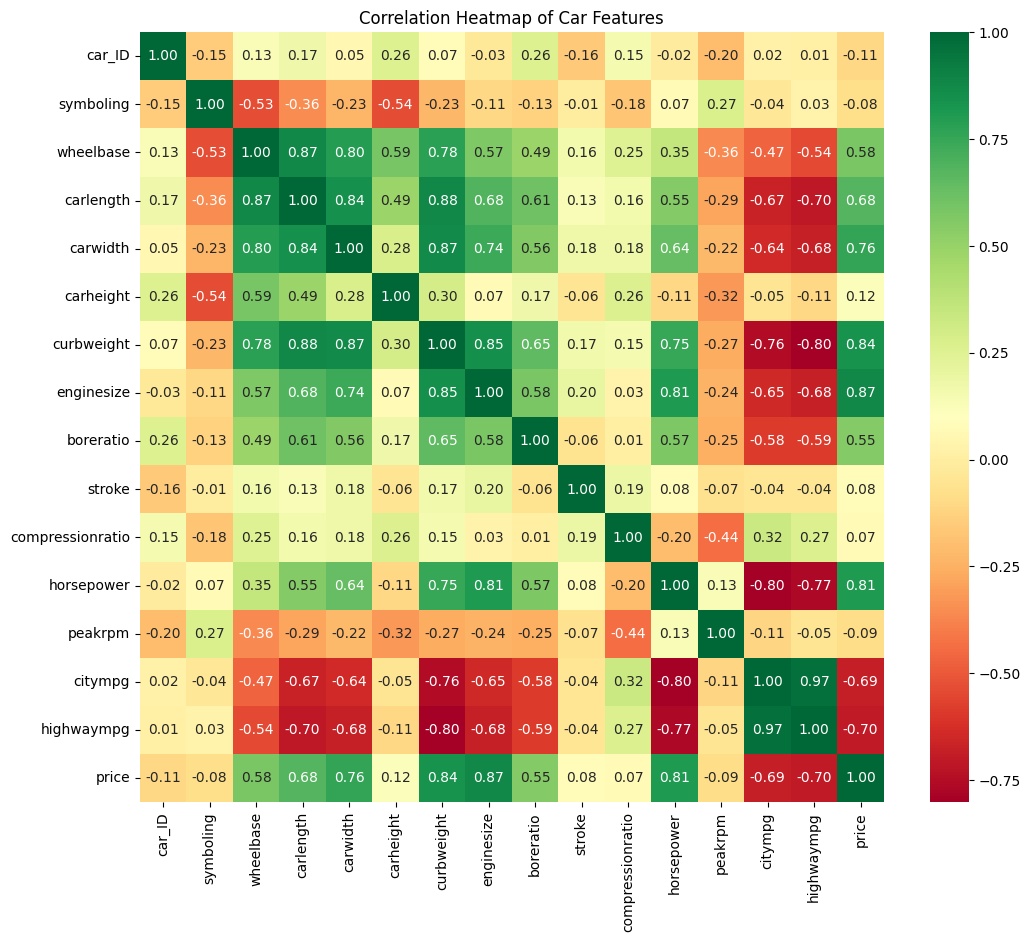

In [19]:
print("Null Values:\n", df.isnull().sum())
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of Car Prices')
plt.show()

plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of Car Features')
plt.show()


## 4. Feature Engineering: Brand Extraction
The `CarName` column contains the brand as the first word. We extract it and fix typos to improve model performance.

In [20]:
df['brand'] = df['CarName'].str.split(' ').str[0]

typo_map = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
    'toyouta': 'toyota',
    'Nissan': 'nissan'
}
df['brand'] = df['brand'].replace(typo_map)
print("Unique Brands:", df['brand'].unique())

Unique Brands: ['alfa-romero' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot' 'plymouth'
 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen' 'volvo']


## 5. Preprocessing & Model Training
We use an ensemble Random Forest model with hyperparameter tuning via Grid Search.

In [21]:
# Feature selection
categorical_features = ['brand', 'fueltype', 'aspiration', 'doornumber', 'carbody', 
                        'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

numerical_features = ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 
                      'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 
                      'horsepower', 'peakrpm', 'citympg', 'highwaympg']

X = df[categorical_features + numerical_features]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline definition
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Hyperparameter tuning
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10, 20],
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'regressor__max_depth': None, 'regressor__n_estimators': 100}


## 6. Evaluation
Comparing predictions with actual values to calculate the R2 score (Accuracy).

In [22]:
y_pred = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Model Accuracy (R2 Score): {r2*100:.2f}%")

Mean Absolute Error: 1263.55
Model Accuracy (R2 Score): 95.88%


## 7. Feature Importance
Visualizing the most influential factors in determining car price.

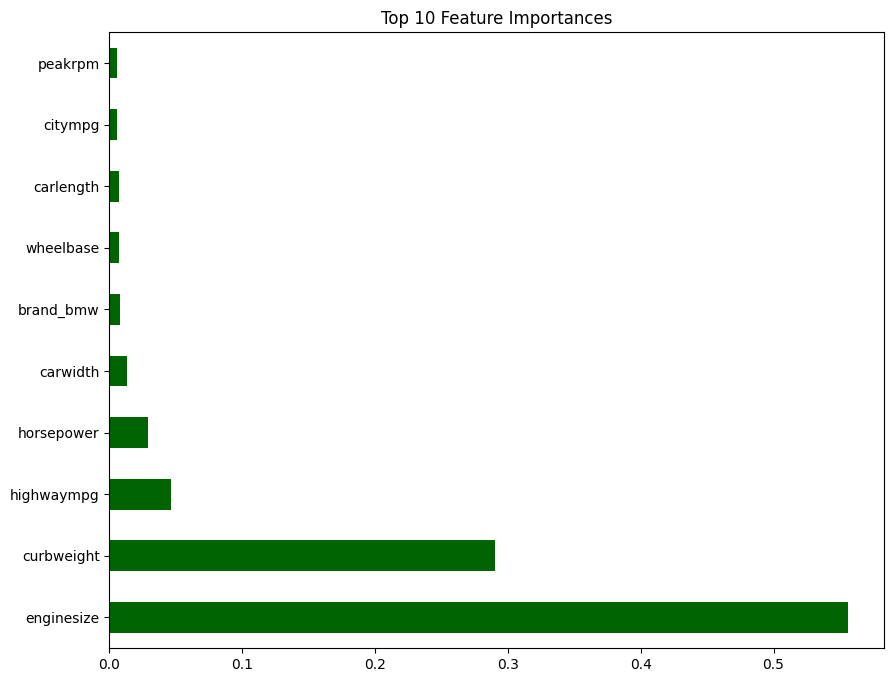

In [23]:
importances = best_model.named_steps['regressor'].feature_importances_
feat_names = numerical_features + list(best_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features))

plt.figure(figsize=(10, 8))
pd.Series(importances, index=feat_names).nlargest(10).plot(kind='barh', color='darkgreen')
plt.title('Top 10 Feature Importances')
plt.show()